# VH Limits

In [1]:
%config InlineBackend.figure_format = 'retina'
import os
import matplotlib.pyplot as plt
import plot_utils as utils

plt.style.use('physics.mplstyle')

import mplhep as hep
hep.style.use("CMS")

In [2]:
# outDir = '/home/submit/{}/public_html/SUEP/limits/debug/'.format(os.environ['USER'])
outDirAN = '/home/submit/{}/SUEP/AN-23-183/images/'.format(os.environ['USER'])
# outDirPaper = '/home/submit/{}/SUEP/EXO-23-002/'.format(os.environ['USER'])
# outDirSupp = '/home/submit/{}/SUEP/EXO-23-002/supplementary/'.format(os.environ['USER'])

saveToAN = False
saveToPaper = False

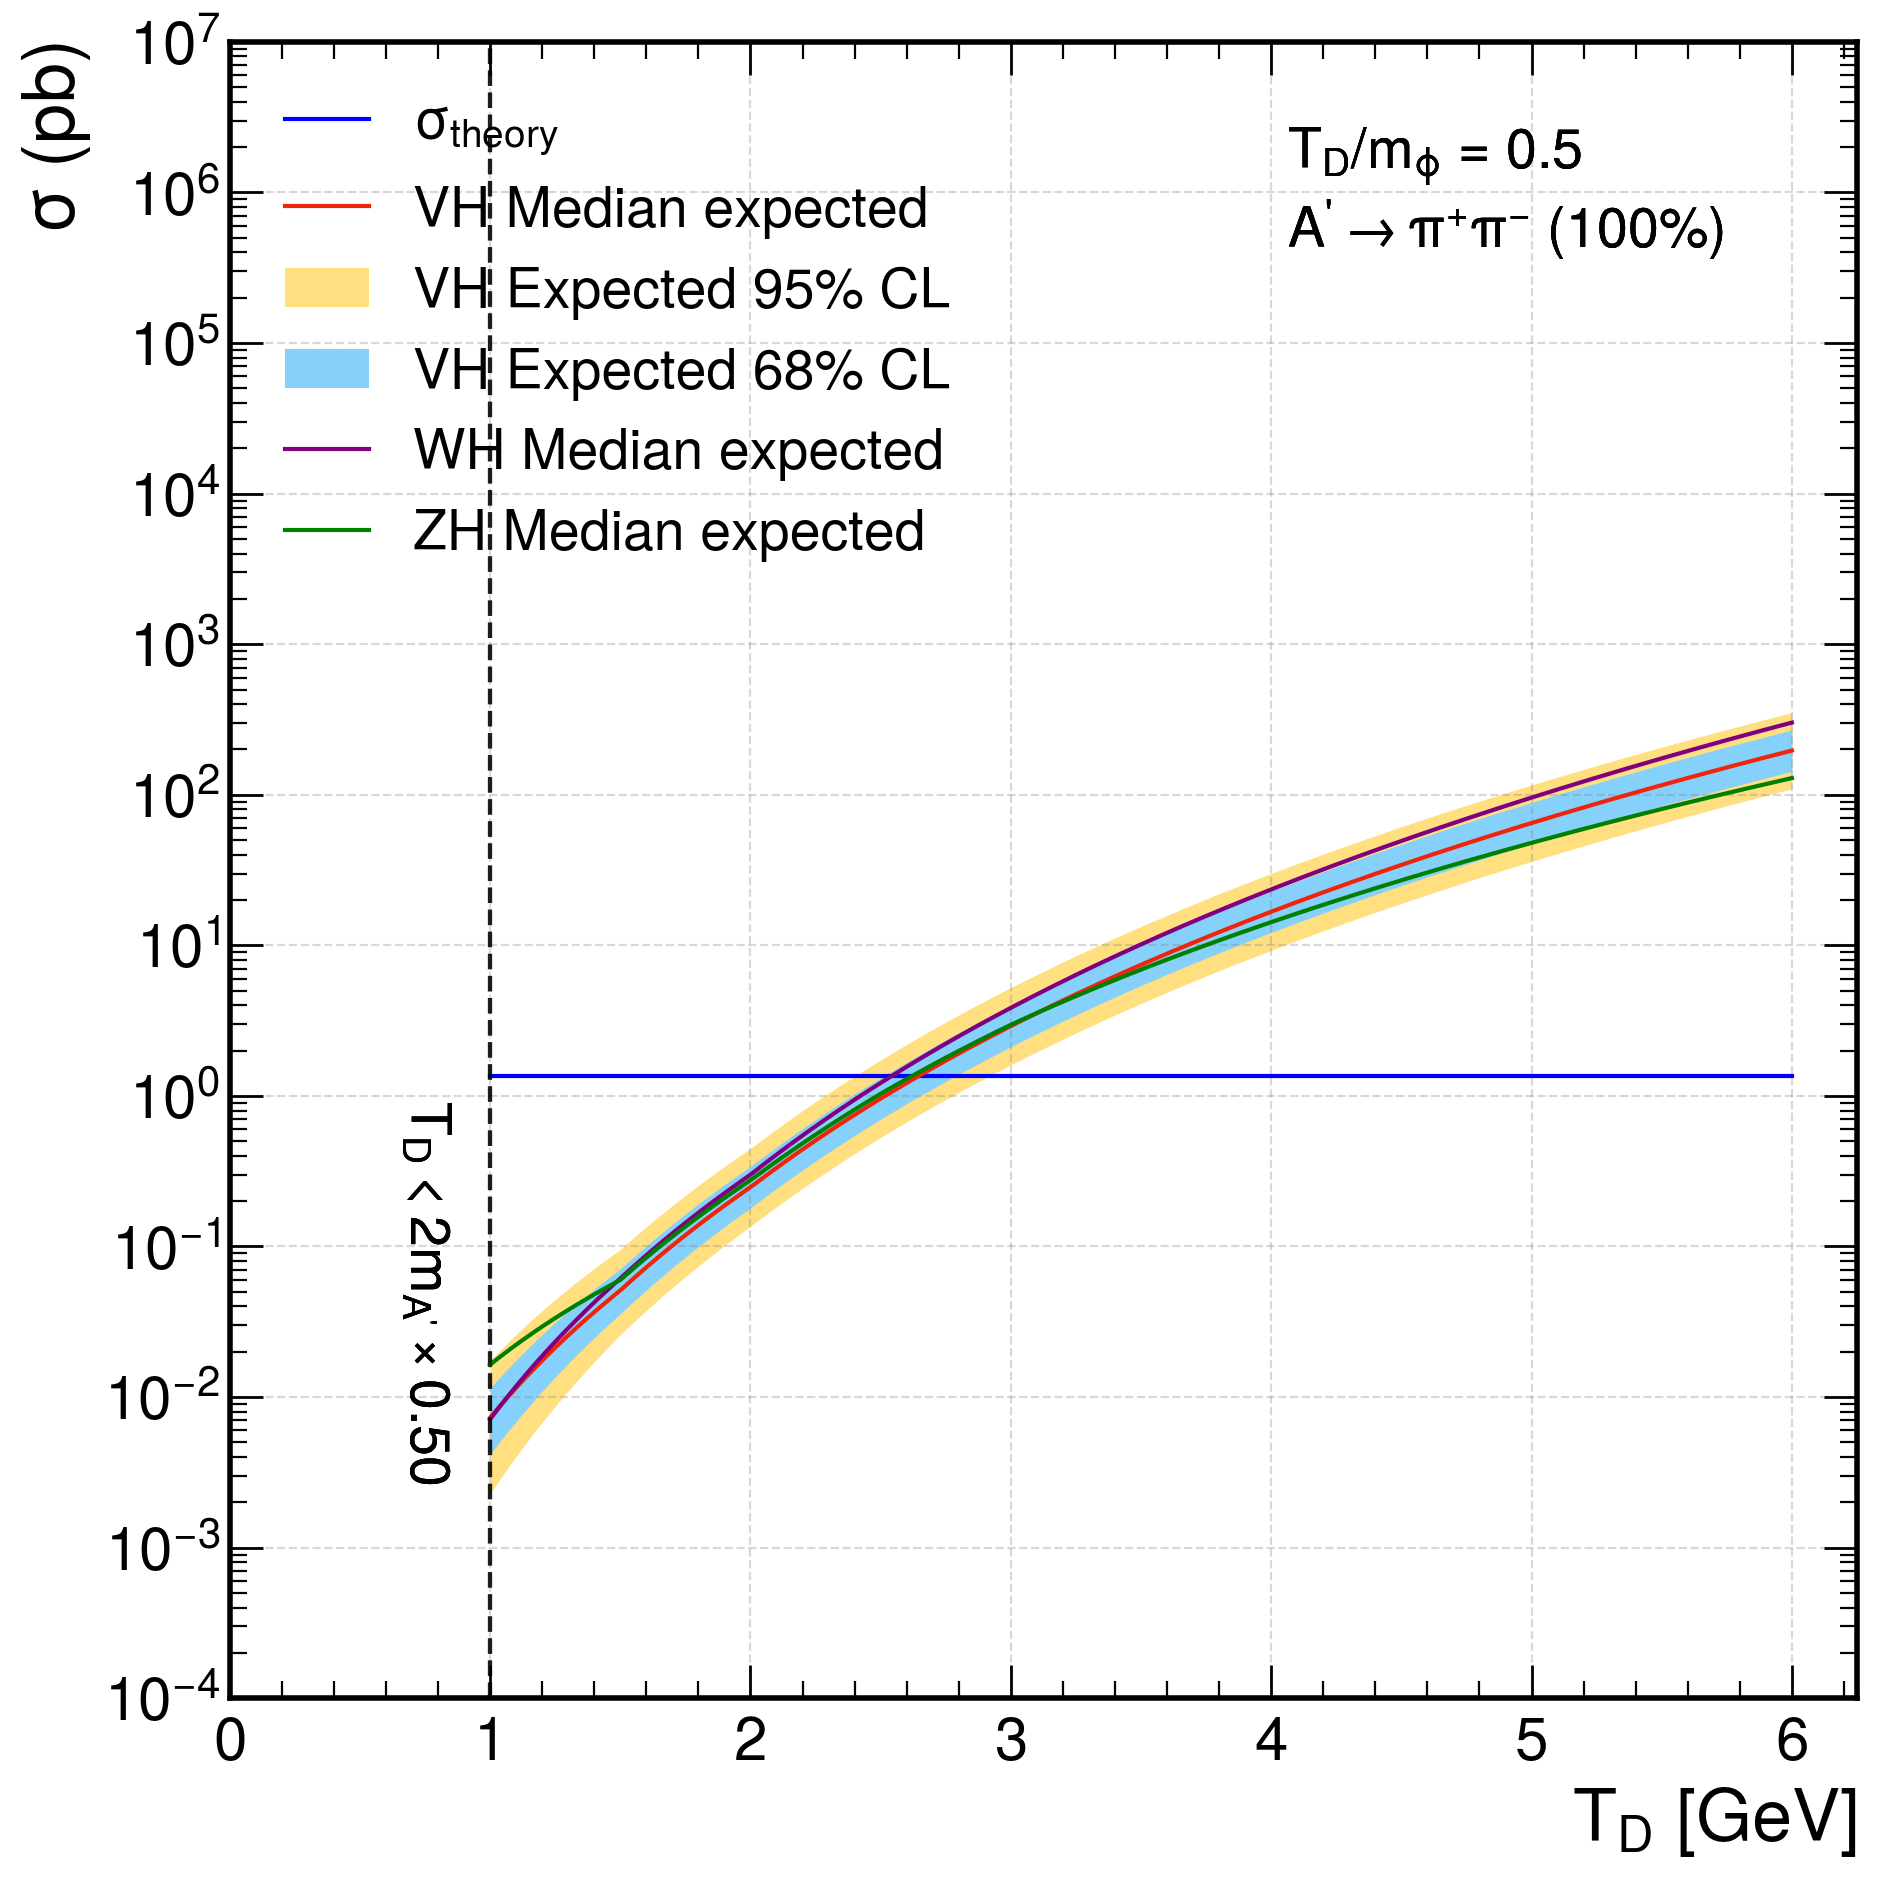

In [ ]:
decay_modes = [
    #'leptonic', 
    #'hadronic',
    'generic'
]
mphi_by_t = [
    #0.25,
    0.5,
    #1.0,
    #2.0,
    #4.0
]

for mode in decay_modes:
    
    for temp_by_mphi in mphi_by_t:
    
        fig = utils.plot_mphi_by_T_limits(
            temp_by_mphi=temp_by_mphi, ms=125, decay=mode,
            path='../cards/Combined/',
            obs_marker='', method='AsymptoticLimits',
            analysis='vh', mu_limit=True, legend_label='VH ',
        )
        ax = utils.plot_mphi_by_T_limits(
            temp_by_mphi=temp_by_mphi, ms=125, decay=mode,
            path='../cards/WH_1_25/',
            method='AsymptoticLimits',
            analysis='wh', mu_limit=True,
            ax=fig.axes[0],
            exp_alpha=0.5,
            obs_marker='',
            bands=False,
            color='purple',
            legend_label = 'WH '
        )
        ax = utils.plot_mphi_by_T_limits(
            temp_by_mphi=temp_by_mphi, ms=125, decay=mode,
            path='/ceph/submit/data/user/l/lavezzo/SUEP/outputs/ZHlimits/',
            method='AsymptoticLimits',
            analysis='zh', mu_limit=True,
            ax=fig.axes[0],
            exp_alpha=0.5,
            obs_marker='',
            bands=False,
            color='green',
            legend_label = 'ZH '
        )
        
        fig.tight_layout()
        if saveToAN:
            utils.savefig(fig, outDirAN, "VH_" + fig.get_label())

# 2D $m_{\phi}$ by $T_D$ plane

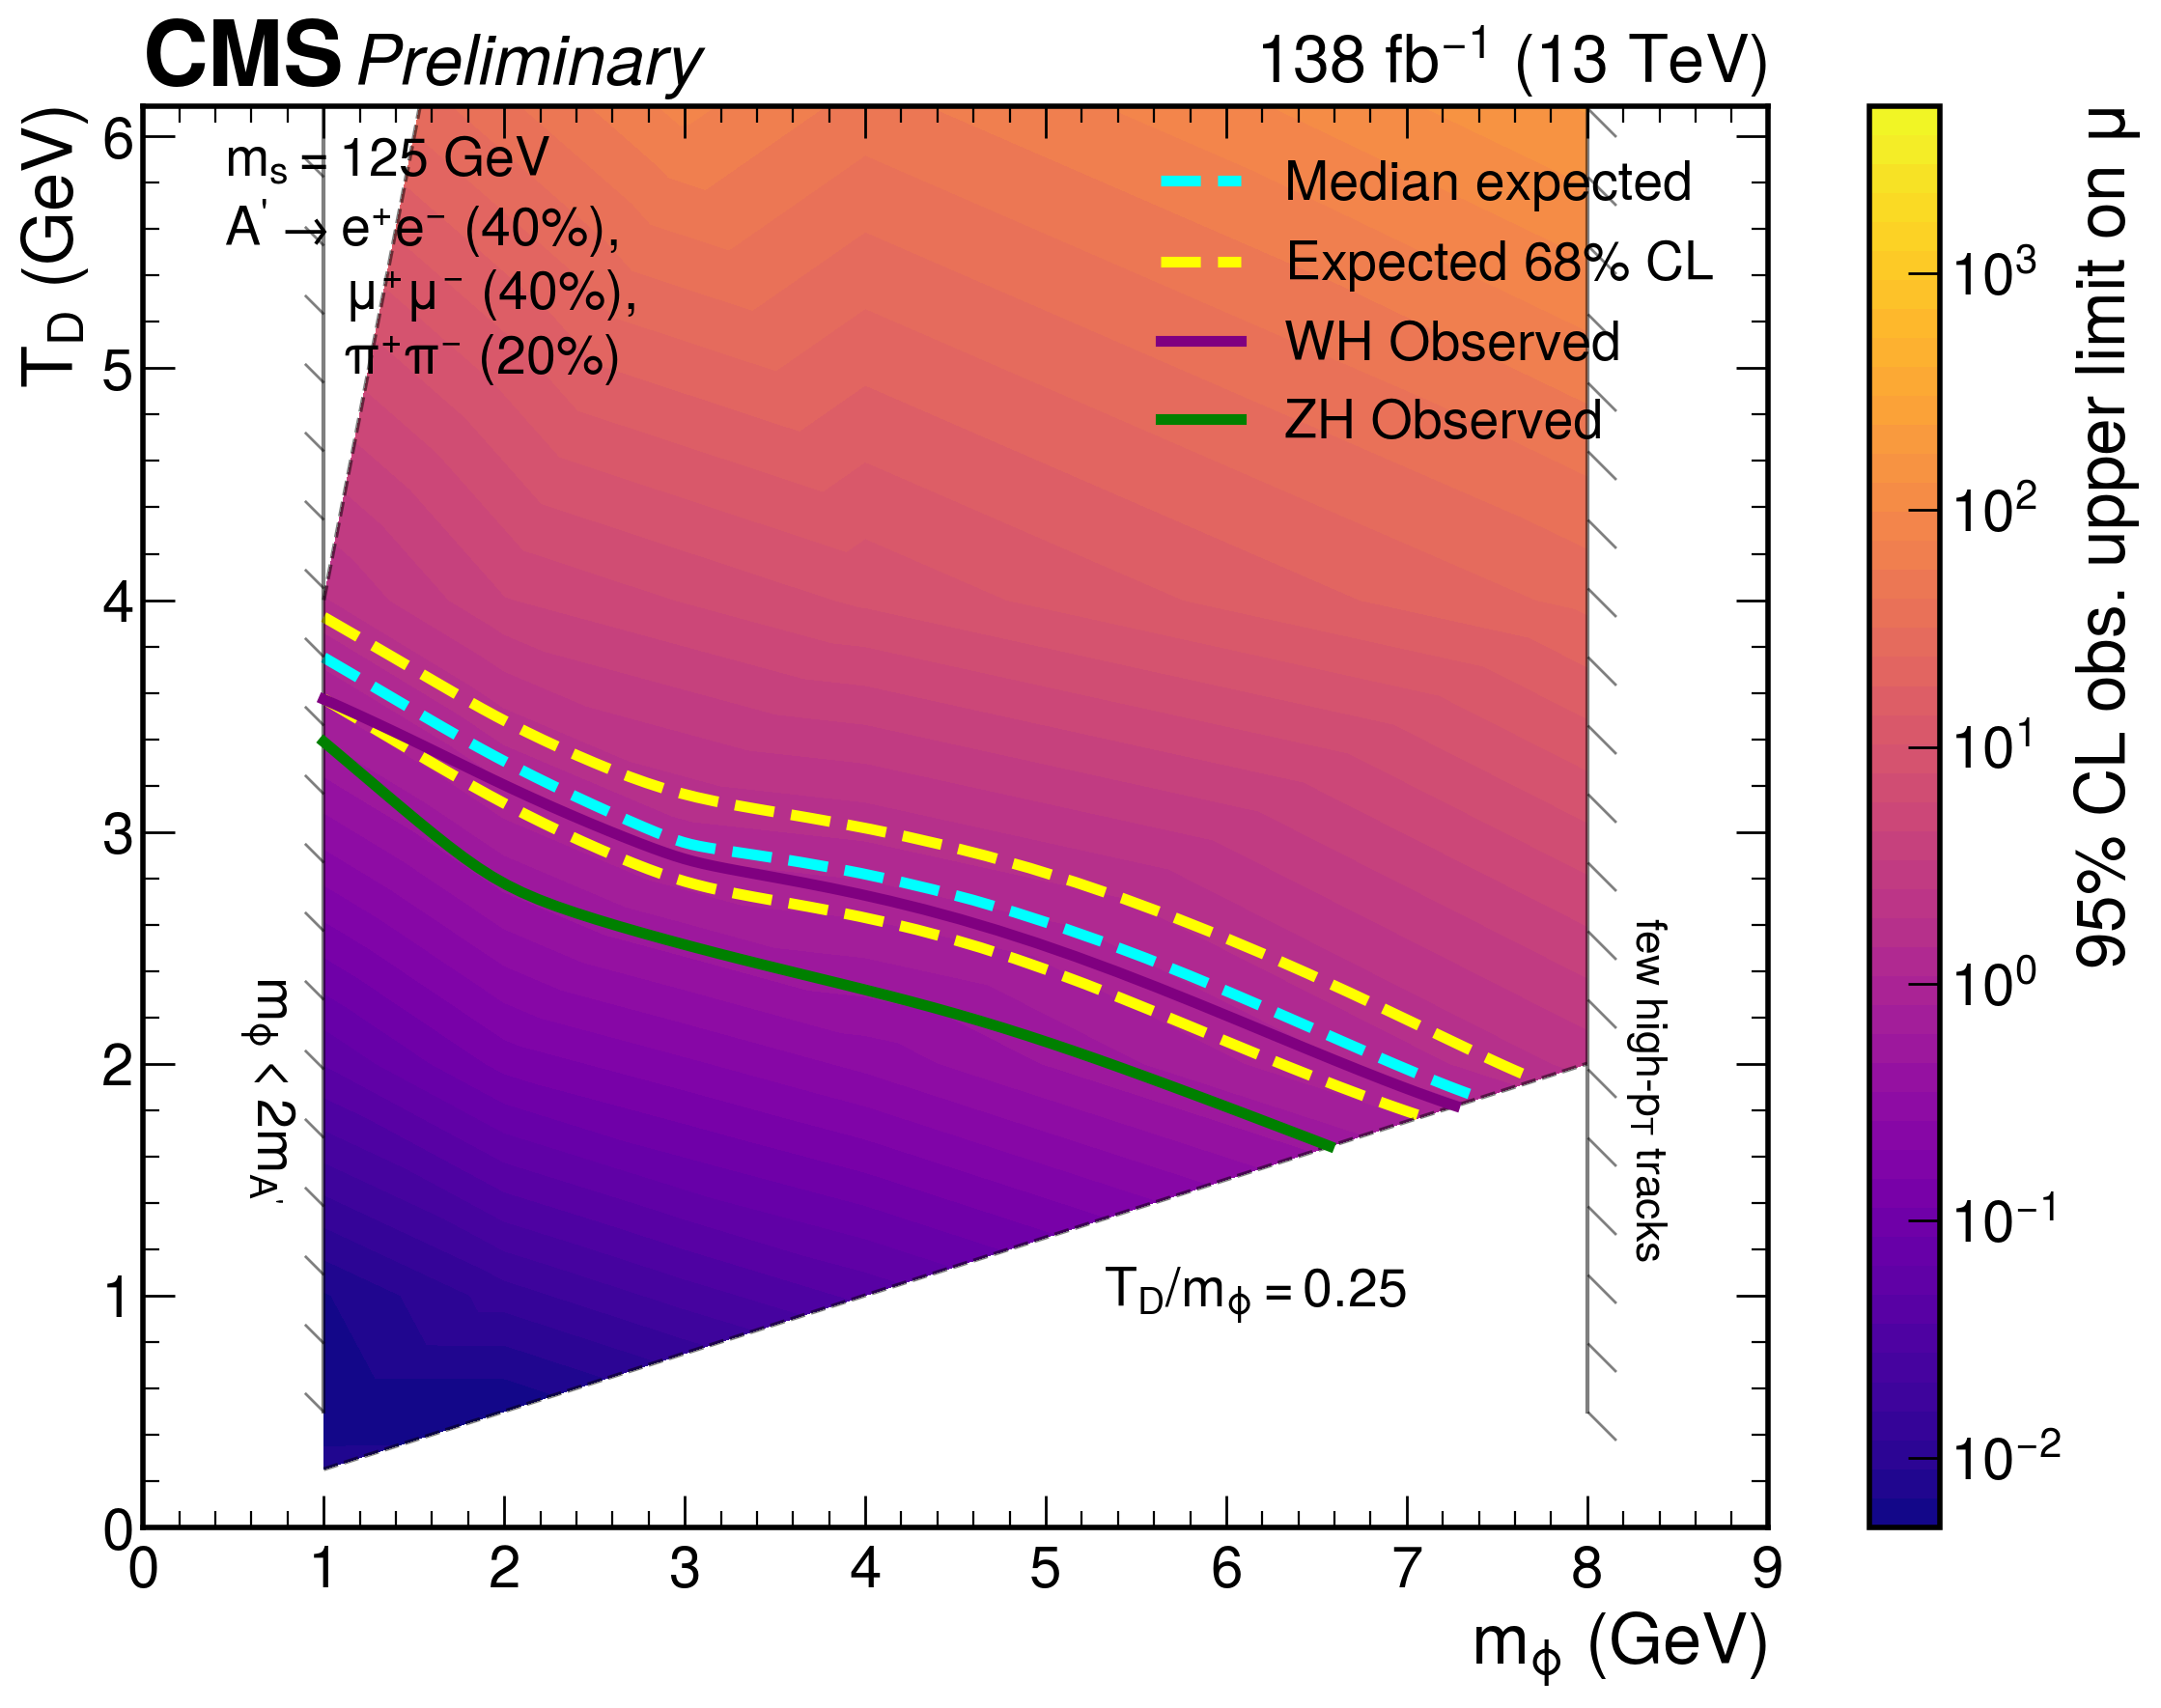

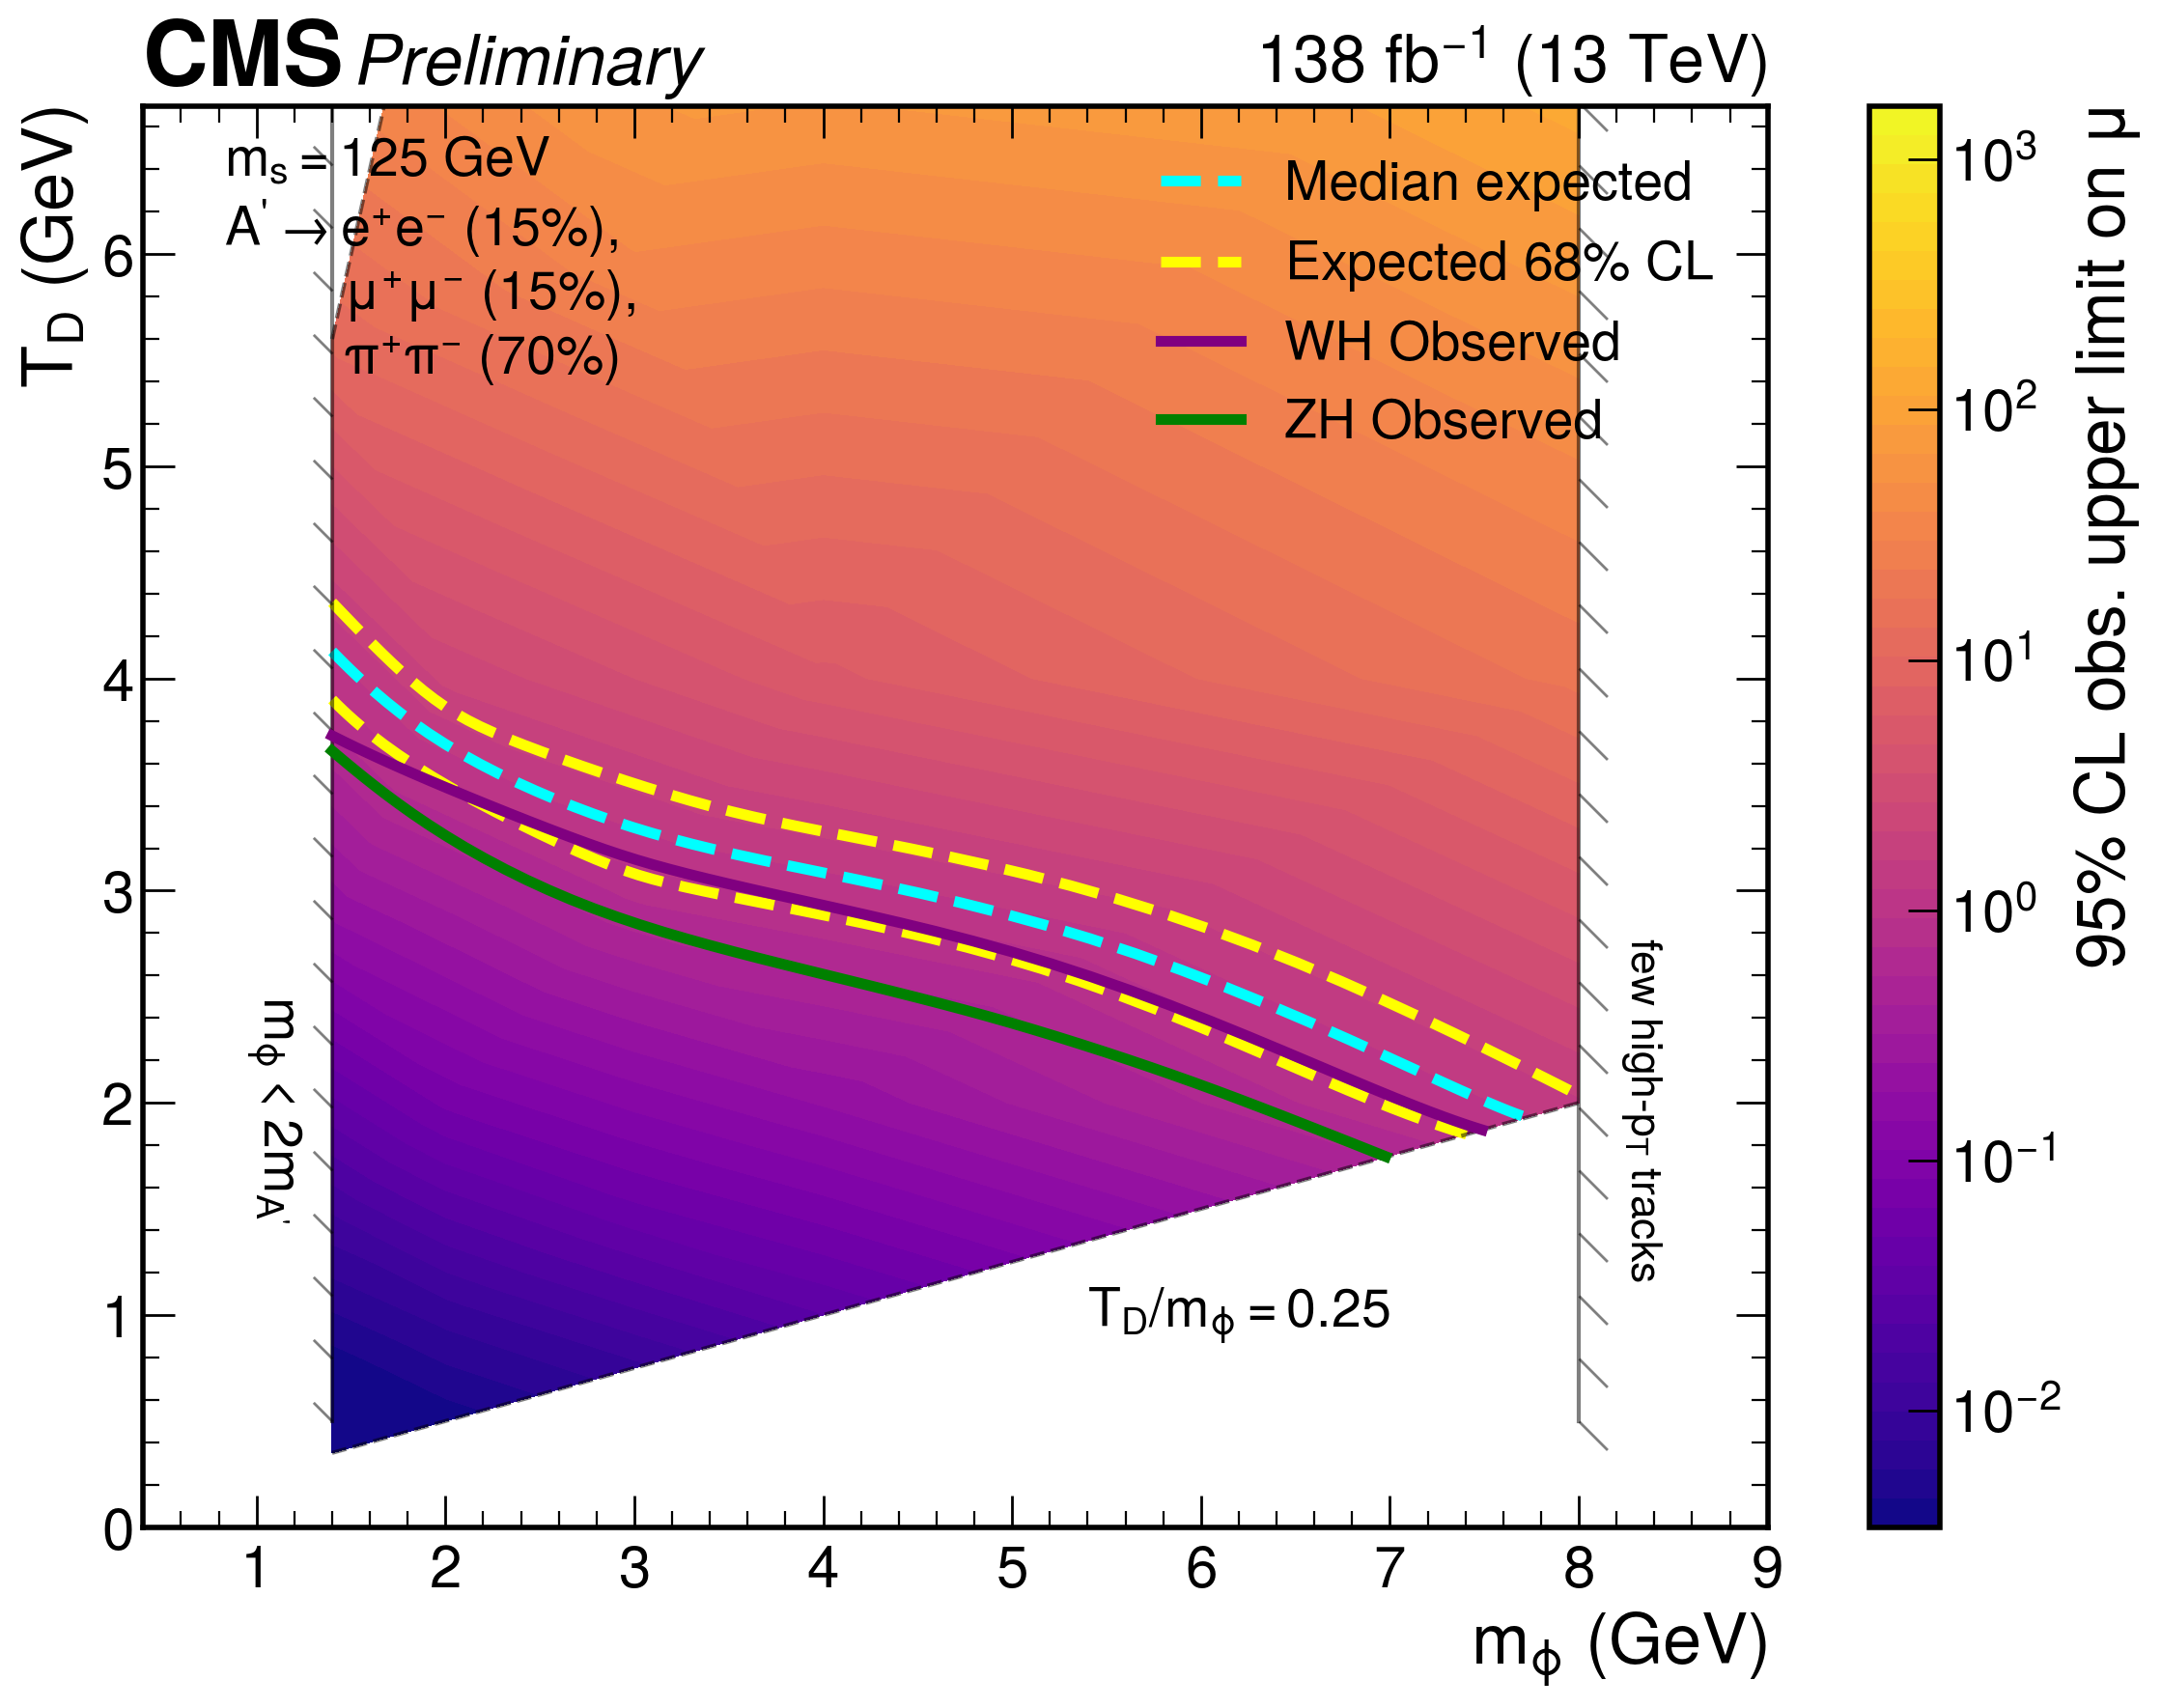

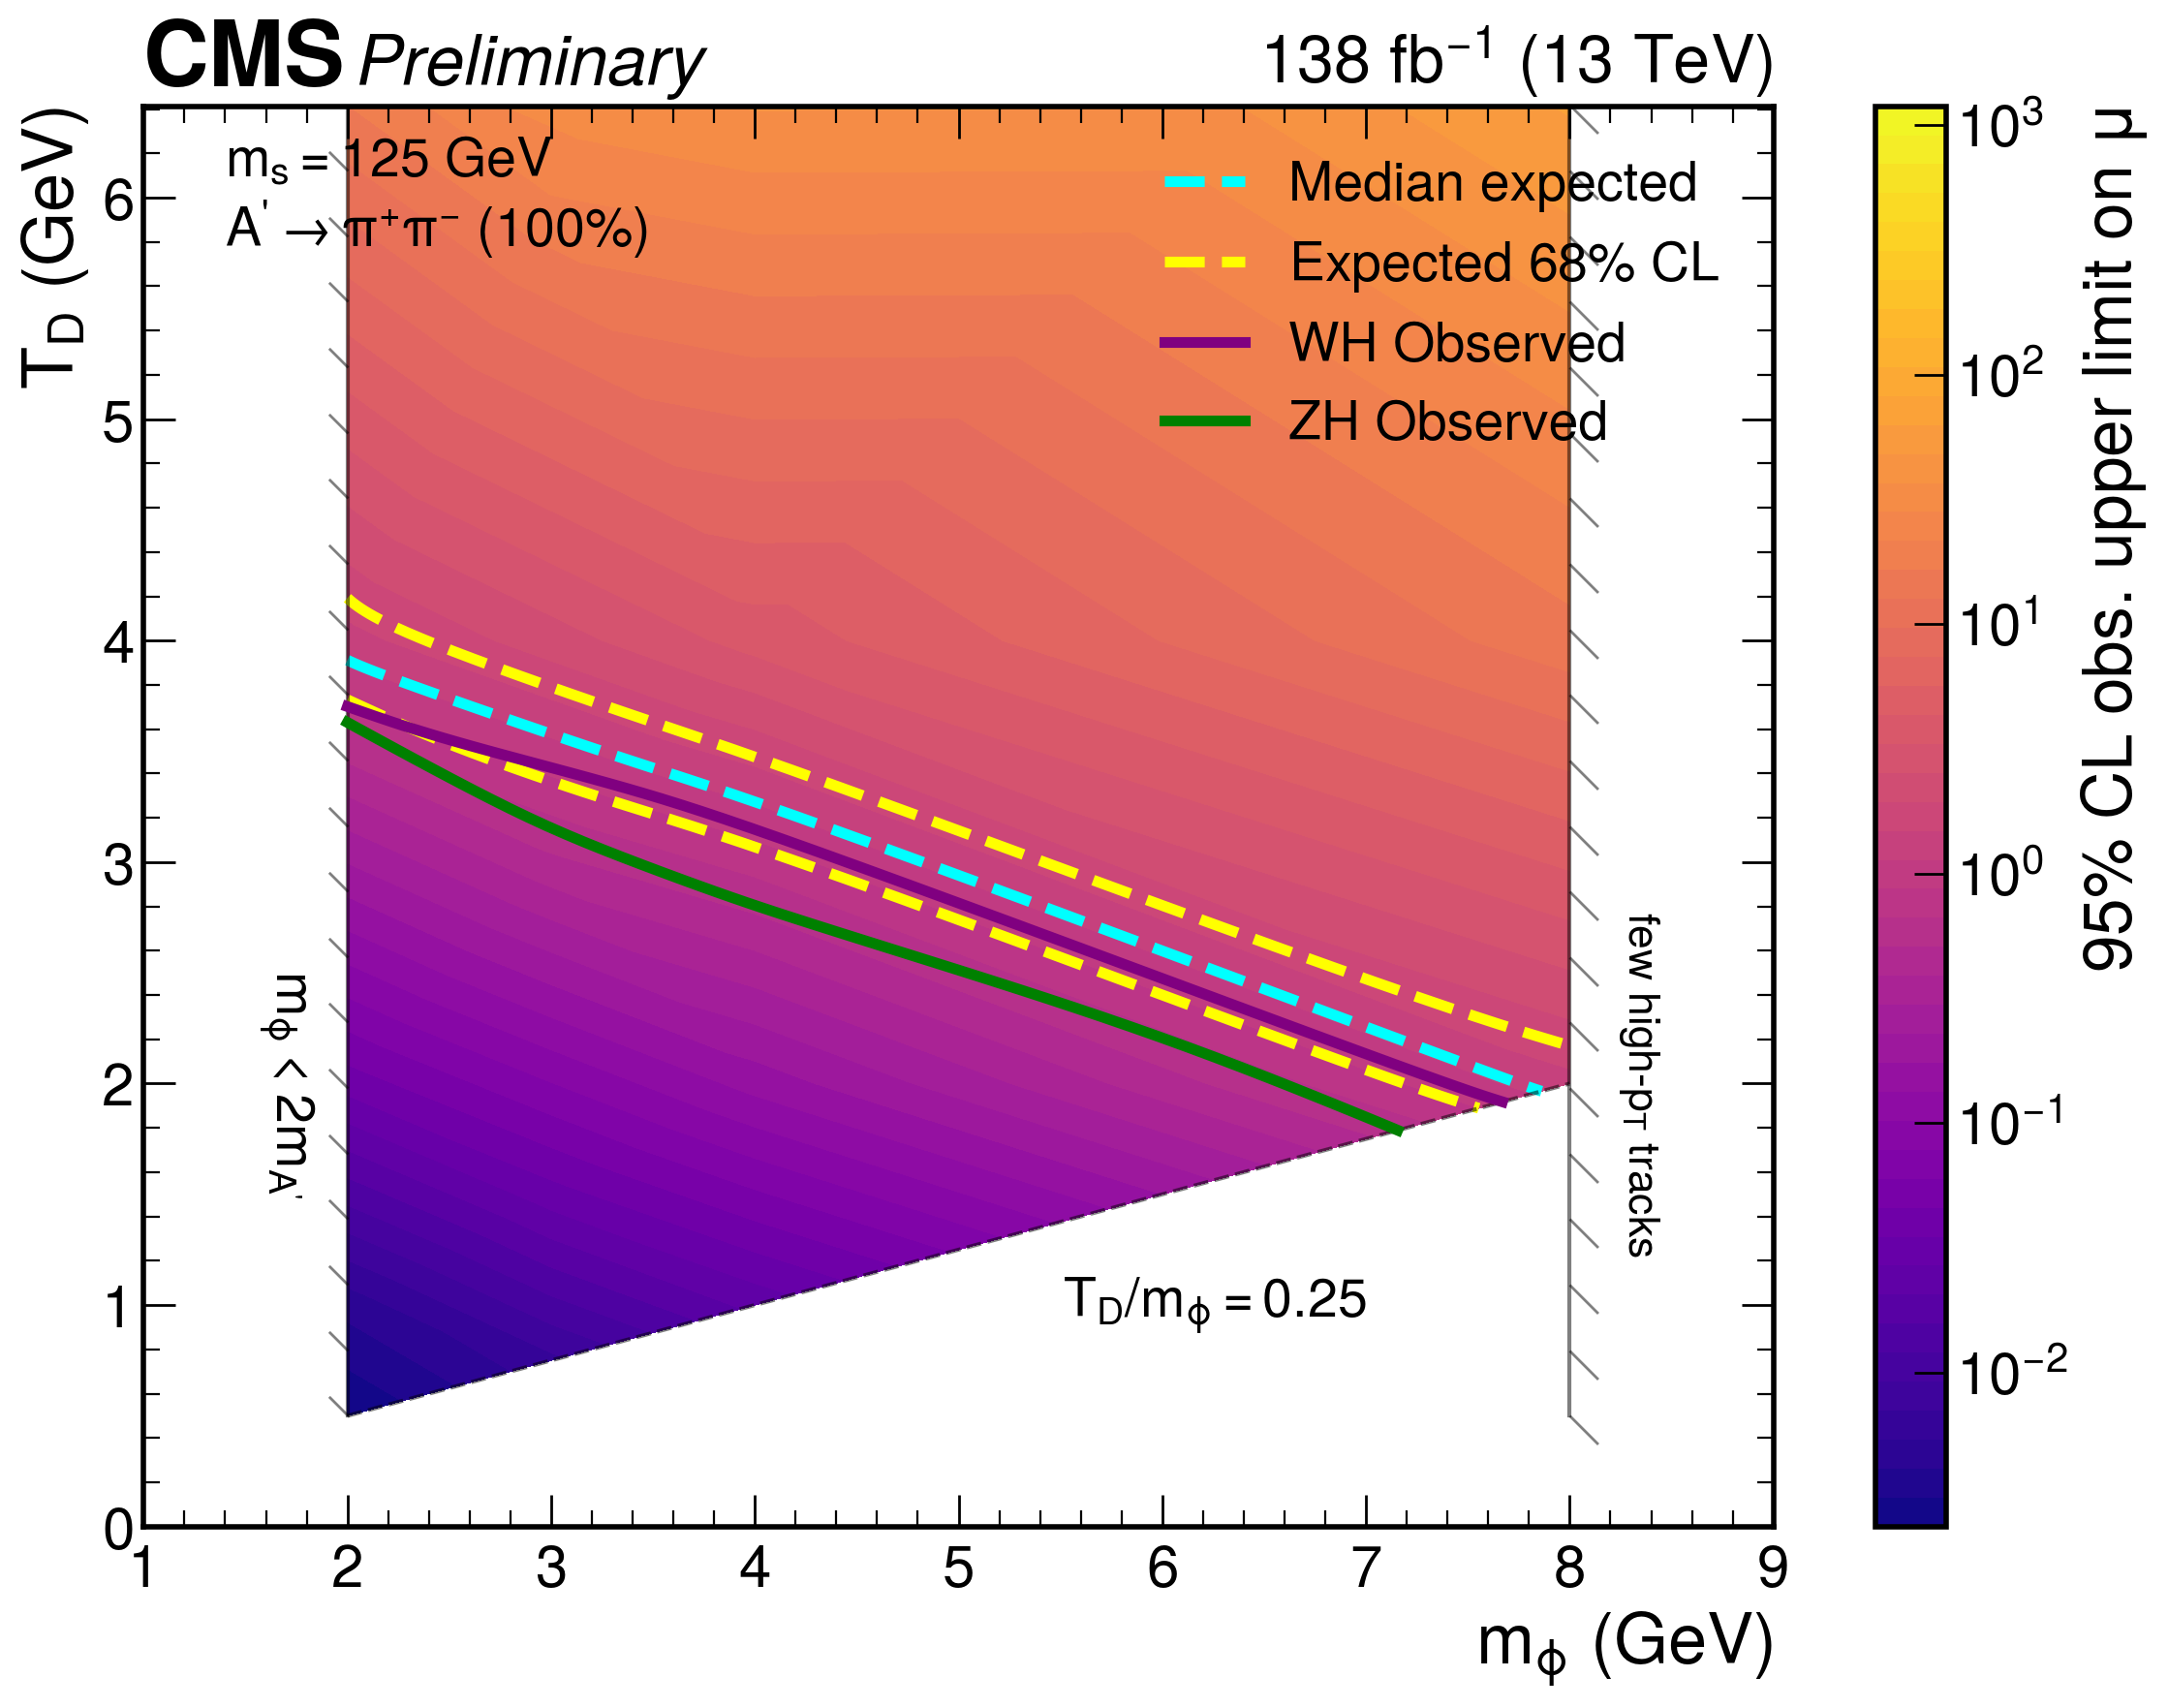

In [7]:
# example usage of the 2D limits function
decay_modes = [
    'leptonic', 
    'hadronic',
    'generic'
]

for decay_mode in decay_modes:
    fig = utils.plot_mPhi_temp_limits(
        ms=125, analysis='vh', decay=decay_mode,
        path='../cards/Combined/', method='AsymptoticLimits',
        tricontour='log', showPoints=False, showObserved=False, showTheoryLines=True, cmsLabel=False, muLimit=True
    )

    # add the WH lines
    wh_lines = utils.plot_mPhi_temp_limits(
        ms=125, analysis='wh', decay=decay_mode,
        path='../cards/WH_1_25/', method='AsymptoticLimits',
        tricontour='log', calculateWithoutPlotting=True, muLimit=True
    )
    ax = fig.get_axes()[0]
    wh_obs_line = wh_lines[-1]
    x_wh_obs, y_wh_obs = utils.interp_limit(wh_obs_line, 4)
    ax.plot(x_wh_obs, y_wh_obs, linestyle = "-", color='purple', label=r"WH Observed",linewidth =4)

    # add the WH lines
    zh_lines = utils.plot_mPhi_temp_limits(
        ms=125, analysis='zh', decay=decay_mode,
        path='/ceph/submit/data/user/l/lavezzo/SUEP/outputs/ZHlimits/', method='AsymptoticLimits',
        tricontour='log', calculateWithoutPlotting=True, muLimit=True
    )
    ax = fig.get_axes()[0]
    zh_obs_line = zh_lines[-1]
    x_zh_obs, y_zh_obs = utils.interp_limit(zh_obs_line, 4)
    ax.plot(x_zh_obs, y_zh_obs, linestyle = "-", color='green', label=r"ZH Observed",linewidth =4)
    
    # pretty up
    ax.legend(loc="upper right", fontsize=20)
    _ = hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

    if saveToAN:
        utils.savefig(fig, outDirAN, "VH_" + fig.get_label())

# 2D best limit in $m_{\phi}$ by $T_D$ plane

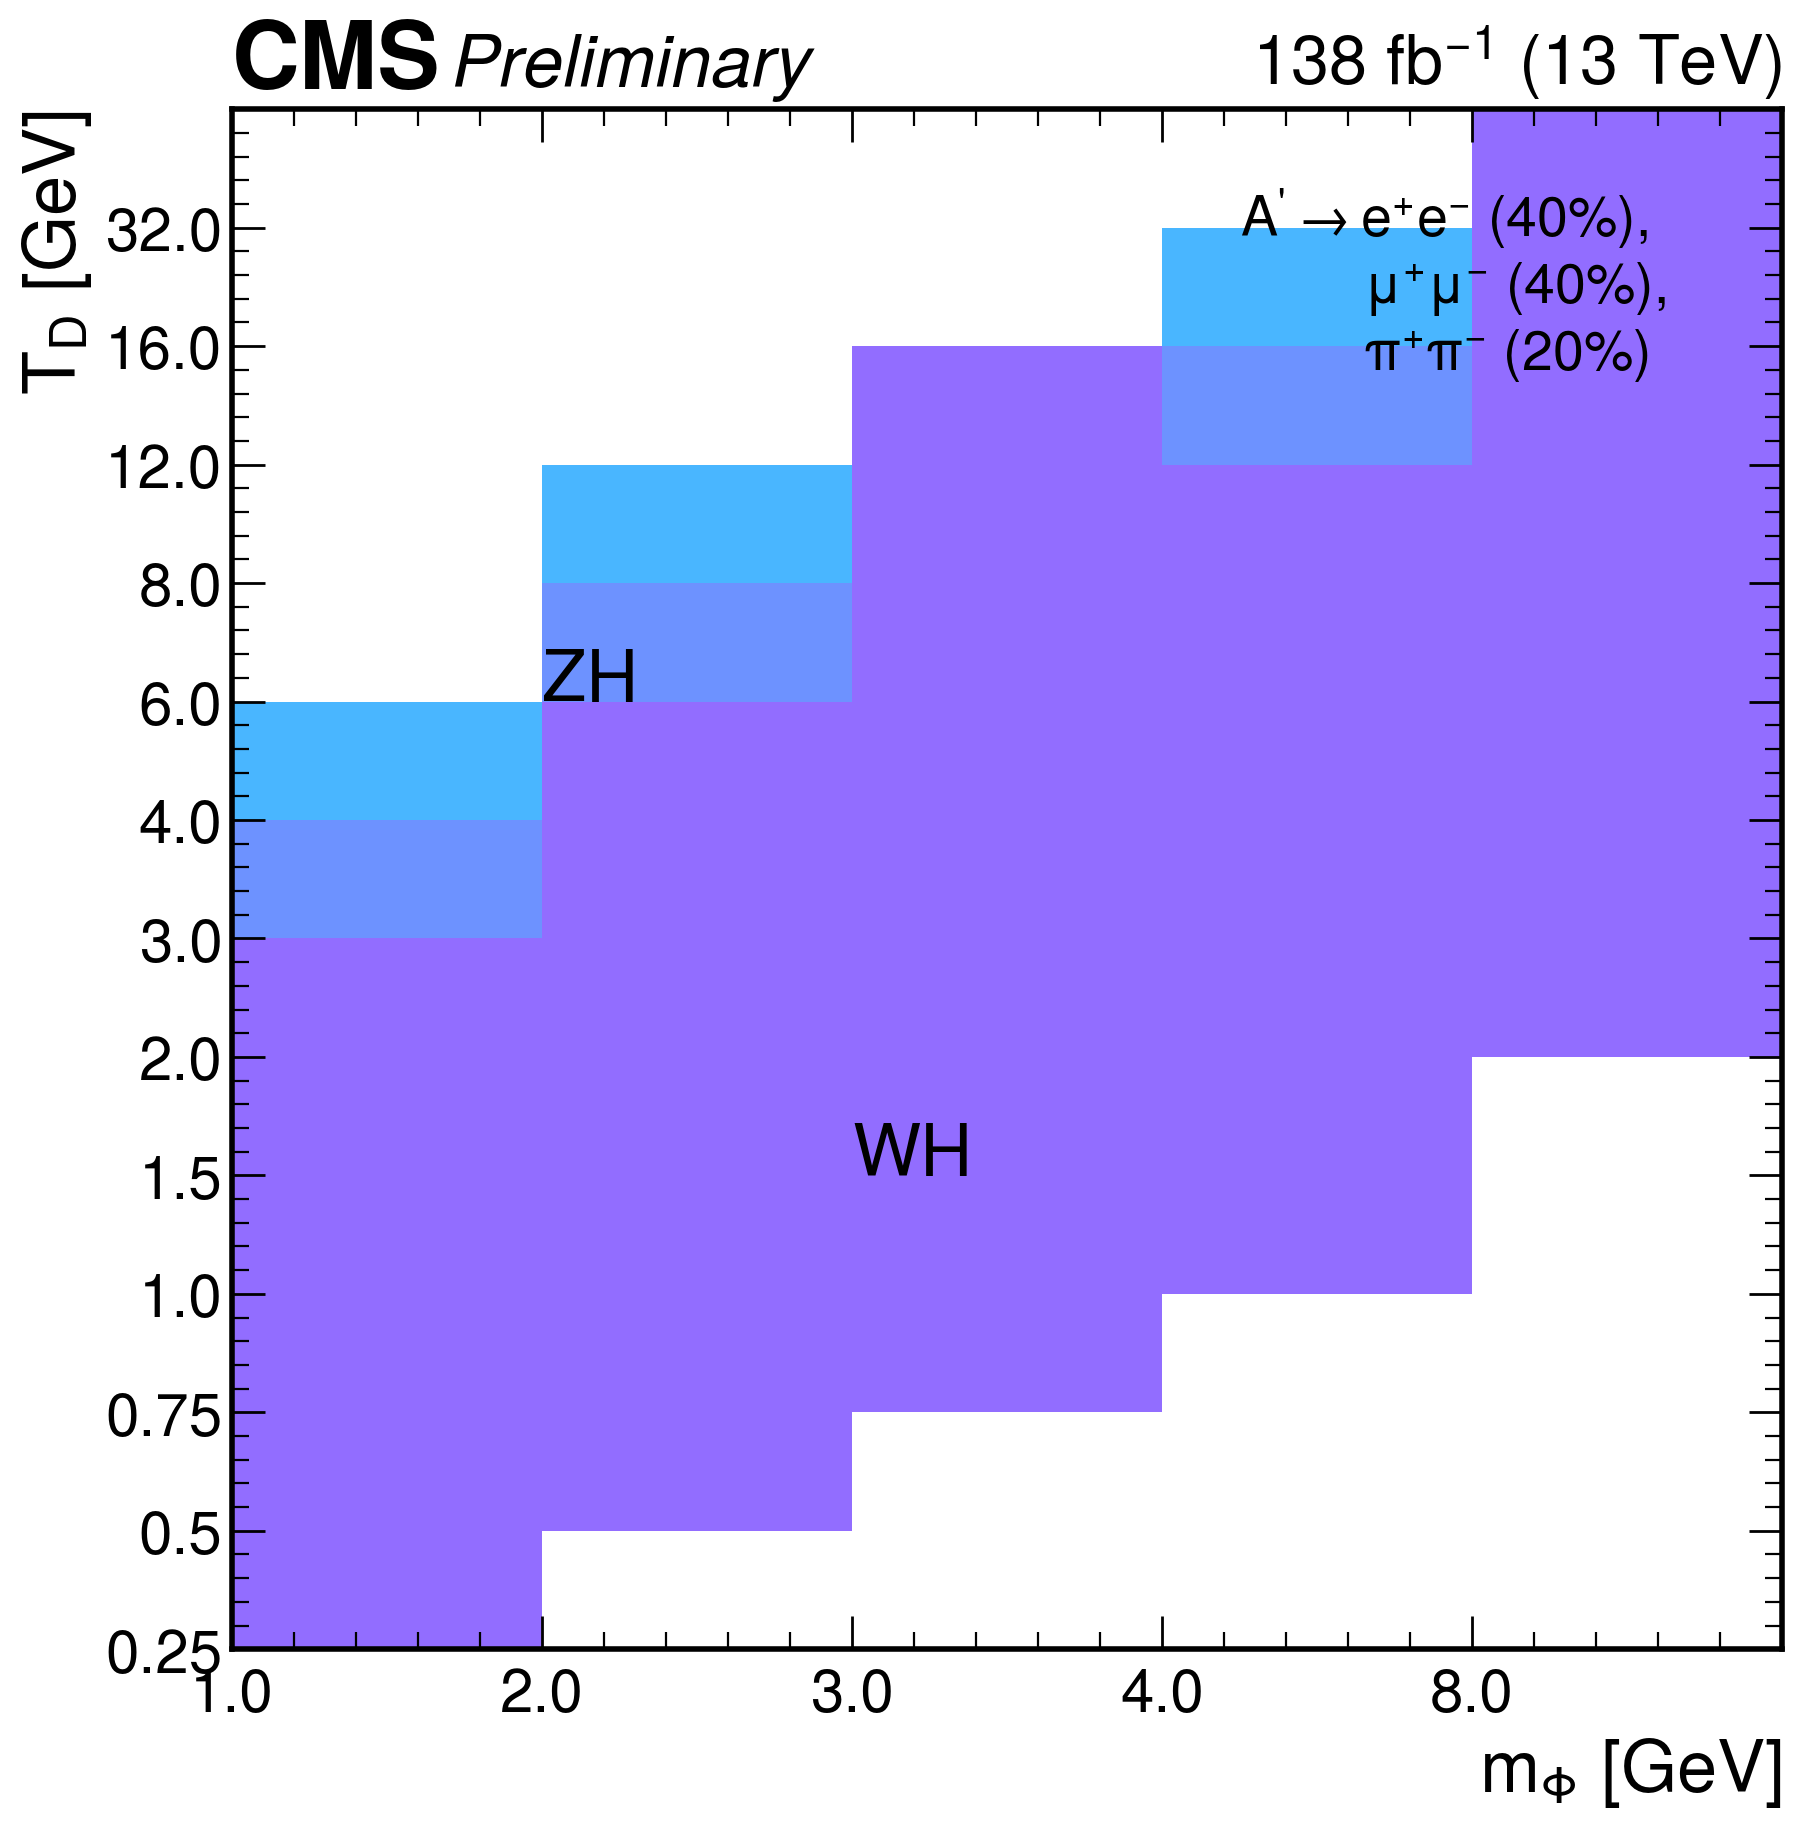

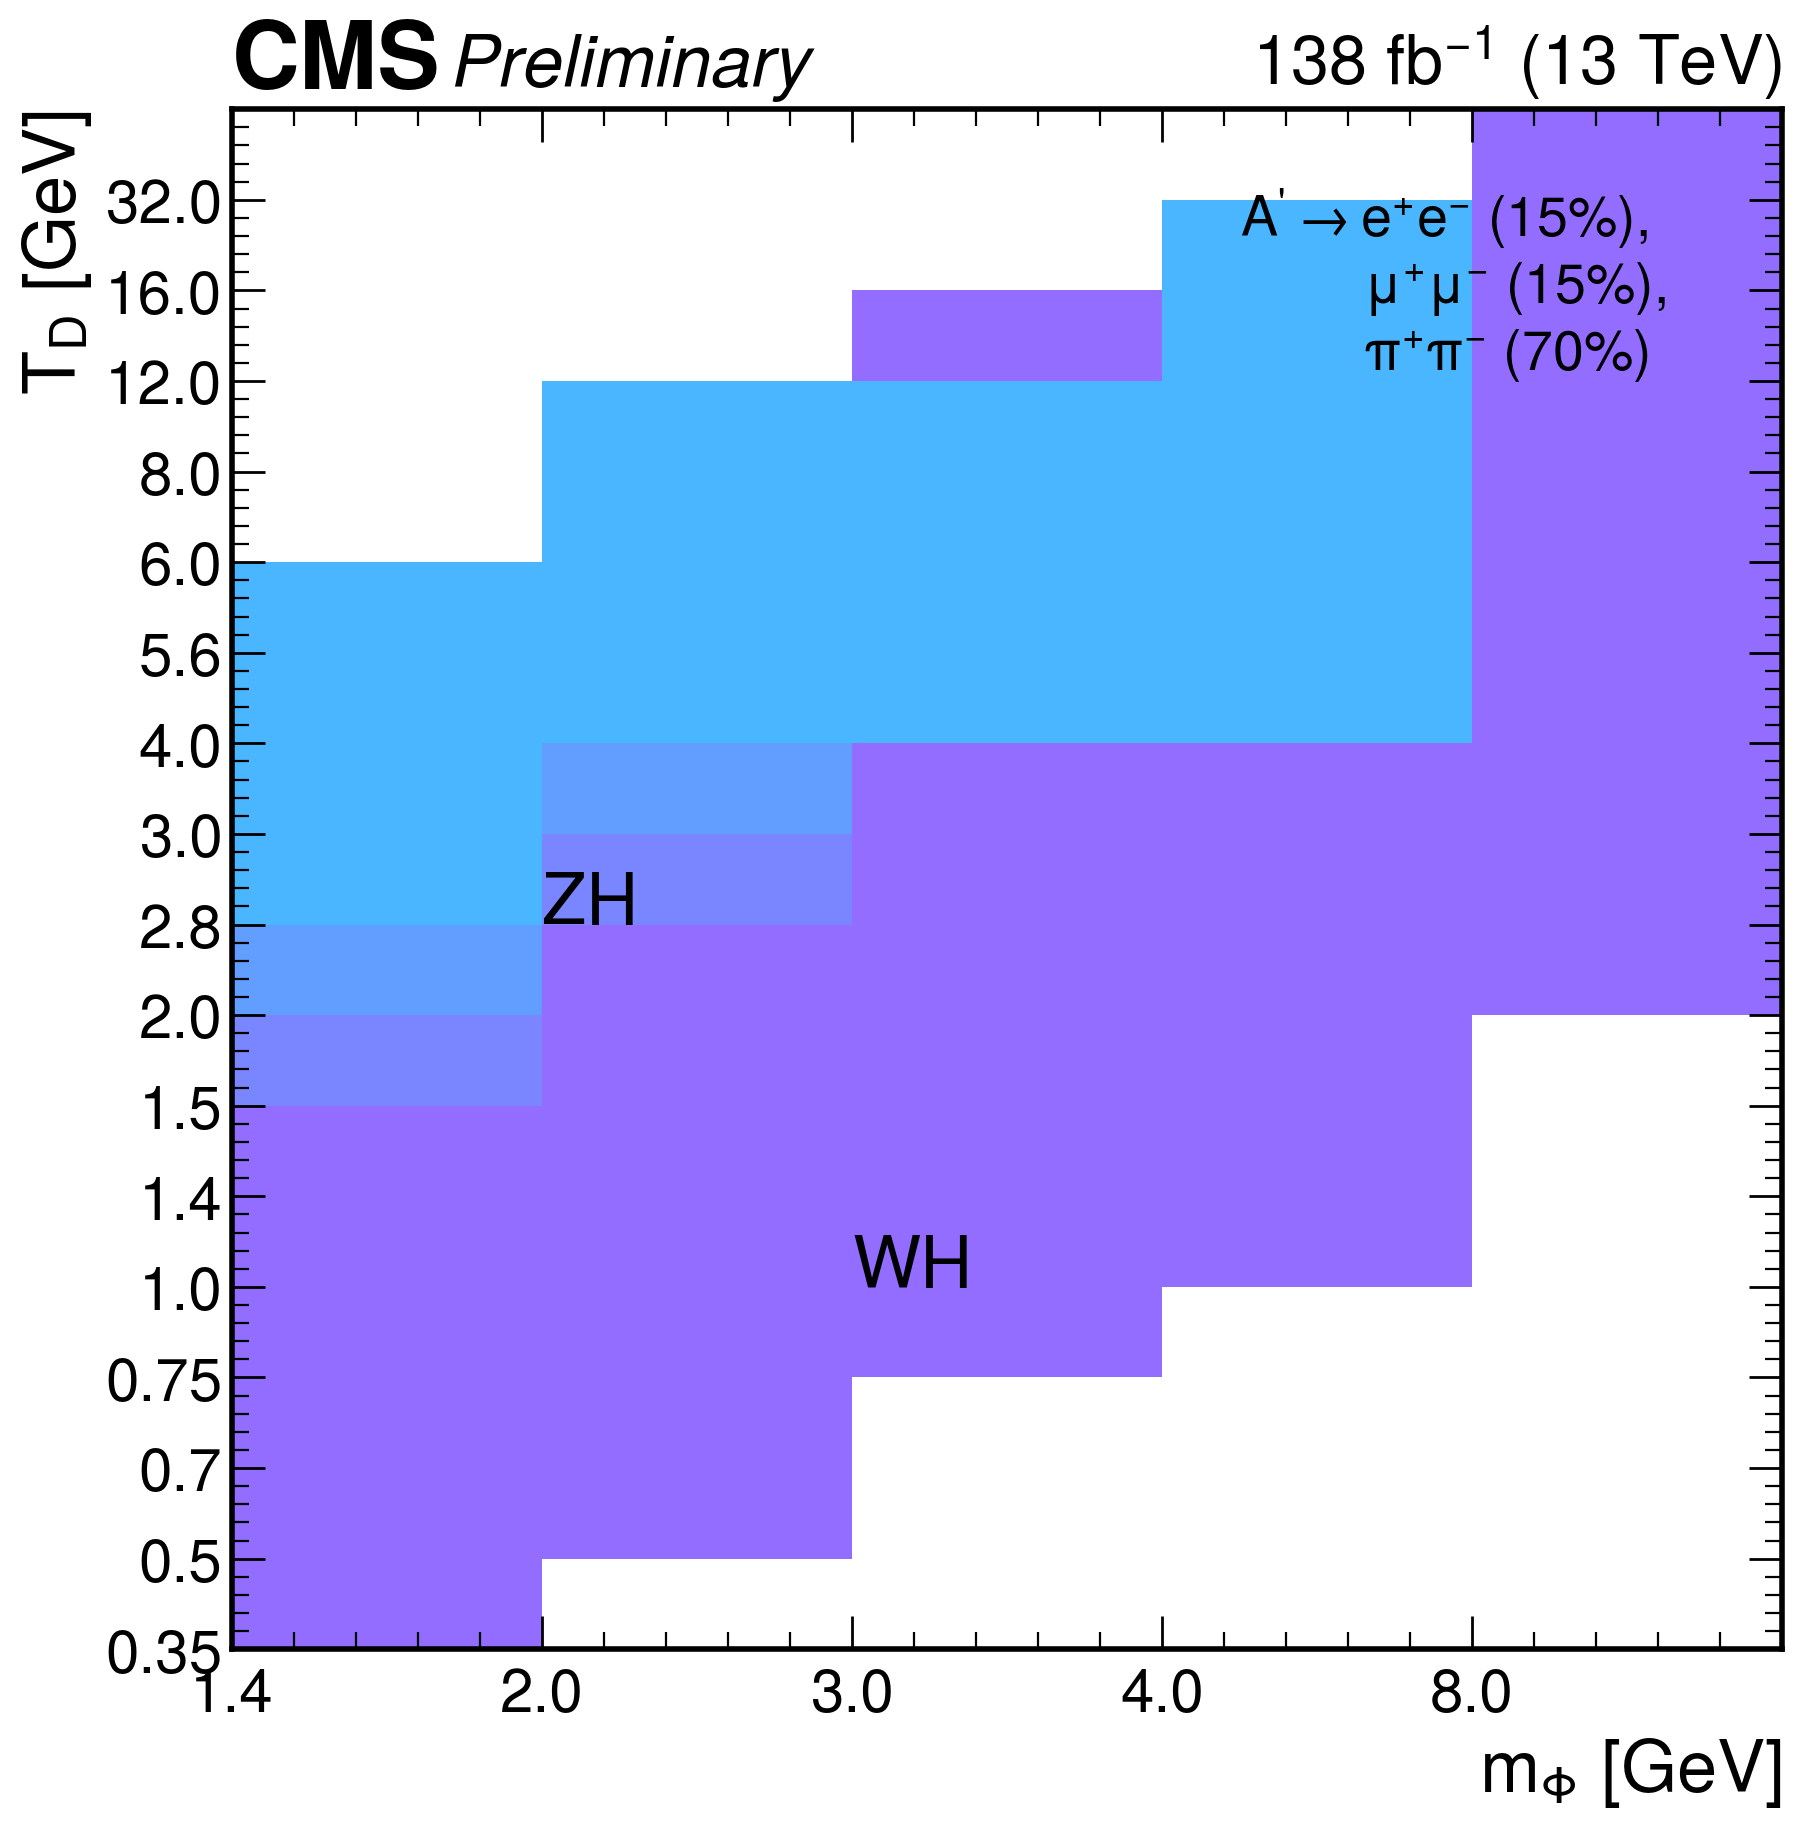

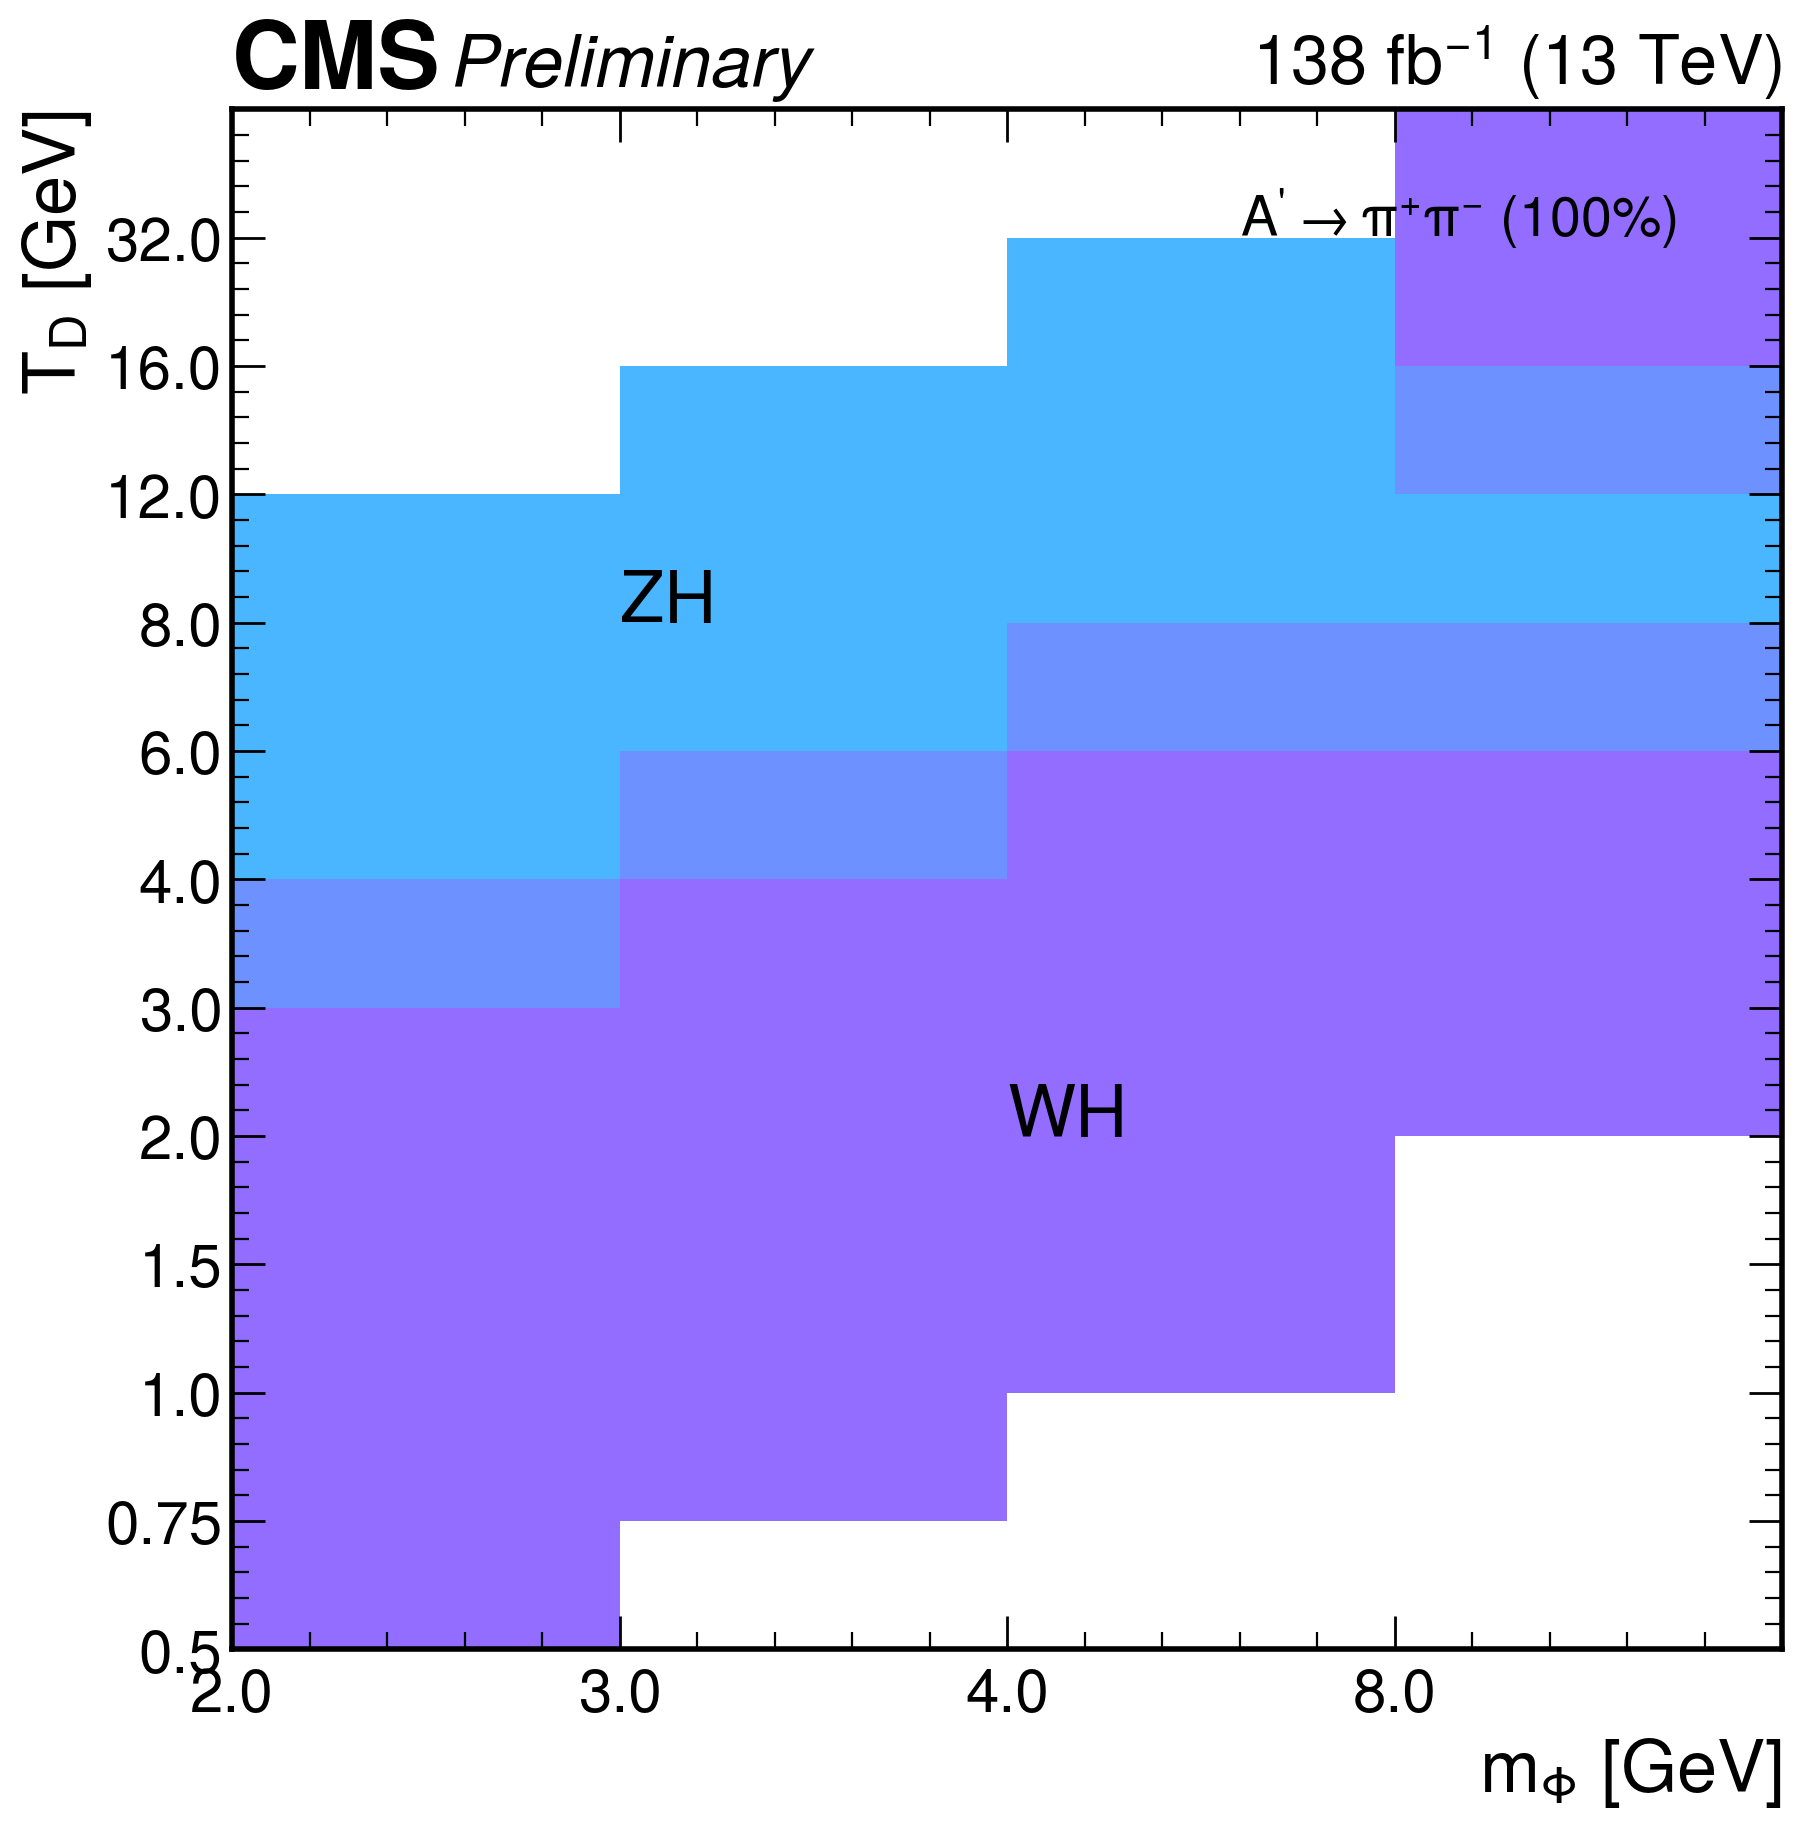

In [4]:
import numpy as np

decays = ['leptonic', 'hadronic', 'generic']

for decay in decays:

    color = utils.make_best_limit_array(
        '../cards/WH_1_25/', 'wh',
        '/ceph/submit/data/user/l/lavezzo/SUEP/outputs/ZHlimits/', 'zh',
        decay=decay,
        interpolate=True
    )

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.pcolormesh(color[:,:,2].T, cmap='cool',vmin=0, vmax=3.5, clip_on=True)
    _ = hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])
    _ = ax.set_yticks(range(color.shape[1]), np.unique(color[:,:,1])[~np.isnan(np.unique(color[:,:,1]))])
    _ = ax.set_xticks(range(color.shape[0]), np.unique(color[:,:,0])[~np.isnan(np.unique(color[:,:,0]))])
    _ = ax.set_ylabel('$T_D$ [GeV]')
    _ = ax.set_xlabel('$m_{\Phi}$ [GeV]')
    _ = ax.text(2,4,'WH')
    _ = ax.text(1,8,'ZH')
    _ = ax.text(
        0.65, 0.95, "{}".format(utils.decaysLabelsWithLineBreaks[decay]),
        fontsize=20, horizontalalignment='left', 
        verticalalignment='top', 
        transform=ax.transAxes,
    )

    if saveToAN:
        utils.savefig(fig, outDirAN, "VH_best_limit_{}".format(decay))

# Limit Table

In [ ]:
vh_limit = utils.get_scan_limits(
    path='../cards/Combined/', analysis='vh', decay='generic',
    method='AsymptoticLimits', temp=4.0, mphi=8.0, ms=125,
    return_xsec=False,
)
wh_limit = utils.get_scan_limits(
    path='../cards/WH_1_25/', analysis='wh', decay='generic',
    method='AsymptoticLimits', temp=4.0, mphi=8.0, ms=125,
    return_xsec=False,
)
zh_limit = utils.get_scan_limits(
    path='/ceph/submit/data/user/l/lavezzo/SUEP/outputs/ZHlimits/', analysis='zh', decay='generic',
    method='AsymptoticLimits', temp=4.0, mphi=8.0, ms=125,
    return_xsec=False,
)
vh_limit_values = vh_limit[0][1][1]
wh_limit_values = wh_limit[0][1][1]
zh_limit_values = zh_limit[0][1][1]

labels = [
    "Expected $2.5\%$ \t",
    "Expected $16\%$ \t",
    "Expected $50\%$ \t",
    "Expected $84\%$ \t",
    "Expected $97.5\%$ \t",
    "Observed \t\t",
]
for iRow in range(len(vh_limit_values)):
    line = ""
    line += labels[iRow] + " & "
    line += "{:.2f} & ".format(zh_limit_values[iRow])
    line += "{:.2f} & ".format(wh_limit_values[iRow])
    line += "{:.2f} ".format(vh_limit_values[iRow])
    line += "\\\\"
    print(line)

Opening input file:  ../cards/Combined/higgsCombinecombinedWZ_mD8.000_T4.000_modegeneric.AsymptoticLimits.mH120.root
Opening input file:  ../cards/WH_1_25/higgsCombineSUEP_mS125.000_mPhi8.000_T4.000_modegeneric.AsymptoticLimits.mH125.root
Opening input file:  /ceph/submit/data/user/l/lavezzo/SUEP/outputs/ZHlimits/higgsCombineCombinedSRCR_SUEP_generic_mS125_mD8.0_T4.00.AsymptoticLimits.mH120.root
Expected $2.5\%$ 	 & 8.70 & 9.33 & 6.83 & \\
Expected $16\%$ 	 & 11.49 & 12.39 & 8.97 & \\
Expected $50\%$ 	 & 15.69 & 17.31 & 12.31 & \\
Expected $84\%$ 	 & 21.44 & 24.63 & 16.88 & \\
Expected $97.5\%$ 	 & 27.90 & 34.04 & 22.10 & \\
Observed 		 & 21.37 & 15.85 & 14.95 & \\


# Correlation Studies

In [ ]:
vh_limit = utils.get_scan_limits(
    path='../cards/official-combined/', analysis='vh', decay='generic',
    method='AsymptoticLimits', mphi=3.0, ms=125,
    return_xsec=False,
)

vh_limit_decorr = utils.get_scan_limits(
    path='../cards/combined-fsr_decorr/', analysis='vh', decay='generic',
    method='AsymptoticLimits', mphi=3.0, ms=125,
    return_xsec=False,
)

vh_exp = [v[1][1][2] for v in vh_limit]
vh_decorr_exp = [v[1][1][2] for v in vh_limit_decorr]
labels = [v[0][2] for v in vh_limit] # temperature values
print("\hline")
print("\hline")
print("$\TD$ & Correlated & Decorrelated \\\\")
print("\hline")
for iRow in range(len(vh_exp)):
    line = ""
    line += str(labels[iRow]) + " & "
    line += "{:.2f} & ".format(vh_exp[iRow])
    line += "{:.2f} ".format(vh_decorr_exp[iRow])
    line += "\\\\"
    print(line)
print("\hline")
print("\hline")

$T_D$ & Correlated & Decorrelated \\
0.75 & 0.01 & 0.01 \\
1.5 & 0.04 & 0.04 \\
12.0 & 203.50 & 203.50 \\
3.0 & 0.57 & 0.57 \\
6.0 & 17.62 & 17.62 \\


In [ ]:
vh_limit = utils.get_scan_limits(
    path='../cards/official-combined/', analysis='vh', decay='generic',
    method='AsymptoticLimits', mphi=3.0, ms=125,
    return_xsec=False,
)

vh_limit_decorr = utils.get_scan_limits(
    path='../cards/combined-isr_decorr/', analysis='vh', decay='generic',
    method='AsymptoticLimits', mphi=3.0, ms=125,
    return_xsec=False,
)

vh_exp = [v[1][1][2] for v in vh_limit]
vh_decorr_exp = [v[1][1][2] for v in vh_limit_decorr]

vh_exp = [v[1][1][2] for v in vh_limit]
vh_decorr_exp = [v[1][1][2] for v in vh_limit_decorr]
labels = [v[0][2] for v in vh_limit] # temperature values
print("\hline")
print("\hline")
print("$\TD$ & Correlated & Decorrelated \\\\")
print("\hline")
for iRow in range(len(vh_exp)):
    line = ""
    line += str(labels[iRow]) + " & "
    line += "{:.2f} & ".format(vh_exp[iRow])
    line += "{:.2f} ".format(vh_decorr_exp[iRow])
    line += "\\\\"
    print(line)
print("\hline")
print("\hline")

\hline
\hline
$T_D$ & Correlated & Decorrelated \\
\hline
0.75 & 0.01 & 0.01 \\
1.5 & 0.04 & 0.04 \\
12.0 & 203.50 & 203.25 \\
3.0 & 0.57 & 0.57 \\
6.0 & 17.62 & 17.62 \\
\hline
\hline


In [ ]:
vh_limit = utils.get_scan_limits(
    path='../cards/official-combined/', analysis='vh', decay='generic',
    method='AsymptoticLimits', mphi=3.0, ms=125,
    return_xsec=False,
)

vh_limit_decorr = utils.get_scan_limits(
    path='../cards/combined-eff_e/', analysis='vh', decay='generic',
    method='AsymptoticLimits', mphi=3.0, ms=125,
    return_xsec=False,
)

vh_exp = [v[1][1][2] for v in vh_limit]
vh_decorr_exp = [v[1][1][2] for v in vh_limit_decorr]

vh_exp = [v[1][1][2] for v in vh_limit]
vh_decorr_exp = [v[1][1][2] for v in vh_limit_decorr]
labels = [v[0][2] for v in vh_limit] # temperature values
print("\hline")
print("\hline")
print("$\TD$ & Correlated & Decorrelated \\\\")
print("\hline")
for iRow in range(len(vh_exp)):
    line = ""
    line += str(labels[iRow]) + " & "
    line += "{:.2f} & ".format(vh_exp[iRow])
    line += "{:.2f} ".format(vh_decorr_exp[iRow])
    line += "\\\\"
    print(line)
print("\hline")
print("\hline")

\hline
$T_D$ & Correlated & Decorrelated \\
\hline
\hline
0.75 & 0.01 & 0.01 \\
1.5 & 0.04 & 0.04 \\
12.0 & 203.50 & 203.25 \\
3.0 & 0.57 & 0.57 \\
6.0 & 17.62 & 17.62 \\
\hline
\hline
